# MarketScout: Система прогнозування цін на авто
Цей ноутбук будує модель машинного навчання, яка прогнозує вартість автомобілів на основі їхніх характеристик.

**Оновлення в цій версії:**
- виправлено парсинг `Fuel` — 453 рядки мали лише об'єм двигуна без типу пального (напр. `"1.6 л."`), через що `Fuel_Type` ставав некоректним значенням;
- причепи (`Причеп`) прибираються ще на етапі очищення даних, а не лише у формі вводу;
- додано нові ознаки: `is_luxury_brand`, `is_automatic_gearbox`, `Engine_missing`, `log_Mileage`, `Age_x_Mileage`, `Decade`;
- порівняння моделей (CatBoost / LightGBM / XGBoost / RandomForest / Ridge) винесено в окремий ноутбук `model_comparison.ipynb` — за його результатами тут лишається **CatBoost**;
- окремо зберігається `valid_categories.pkl`, який раніше очікувався бекендом, але не генерувався жодним ноутбуком.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from catboost import CatBoostRegressor
import joblib

RANDOM_SEED = 42
CURRENT_YEAR = 2026
N_FOLDS = 5      # кількість фолдів для Cross-Validation
MIN_COUNT = 10   # мінімальна кількість записів, щоб марка/модель НЕ вважалась рідкісною

# Статичний список преміум/люкс марок для ознаки is_luxury_brand.
# Це доменні знання (не рахуються з даних), тому витоку даних тут немає.
LUXURY_MARKS = {
    'Aston Martin', 'BMW-Alpina', 'Lamborghini', 'Rolls-Royce', 'Ferrari',
    'Bentley', 'Porsche', 'Maserati', 'Lexus', 'Land Rover', 'Jaguar',
    'Mercedes-Benz', 'BMW', 'Audi', 'Lucid', 'Genesis',
}
# Коробки передач, які поводяться як "автоматичні" для водія
AUTOMATIC_LIKE = {'Автомат', 'Типтронік', 'Варіатор', 'Робот'}

In [2]:
data = pd.read_csv("../data/new_clean_data_twenty.csv")
df = data.copy()

print(f"Розмір датасету: {df.shape[0]} рядків, {df.shape[1]} колонок")
print(f"Пропуски:\n{df.isnull().sum()}")
display(df.head(3))

Розмір датасету: 20000 рядків, 9 колонок
Пропуски:
Unnamed: 0      0
ID              0
Mark           27
Model         301
Year            0
Price_USD       0
Mileage         0
Fuel            0
Gearbox         0
dtype: int64


,Unnamed: 0,ID,Mark,Model,Year,Price_USD,Mileage,Fuel,Gearbox
0,0,40427785,Peugeot,307,2005,3800,160,Бензин,Ручна / Механіка
1,1,40427759,BMW,X3,2021,29985,79,"Бензин, 2 л.",Автомат
2,2,40427740,Audi,A5,2020,30999,67,"Бензин, 1.98 л.",Автомат


In [3]:
data.columns

Index(['Unnamed: 0', 'ID', 'Mark', 'Model', 'Year', 'Price_USD', 'Mileage',
       'Fuel', 'Gearbox'],
      dtype='object')

## Очищення та підготовка даних

In [4]:
df = df.drop(columns=['ID', 'Engine'], errors='ignore')
df = df[df['Price_USD'] > 0].copy()

# FIX: причепи прибираємо тут, а не тільки фільтром у Streamlit-формі —
# інакше вони потрапляли у тренувальні дані й псували розподіл цін
before_trailers = len(df)
df = df[df['Mark'] != 'Причеп'].copy()
print(f"Прибрано причепів: {before_trailers - len(df)}")
print(f"Після базового очищення: {len(df)} рядків")

Прибрано причепів: 4
Після базового очищення: 19907 рядків


In [5]:
df['Age'] = CURRENT_YEAR - df['Year']

df = df[(df['Age'] >= 0) & (df['Age'] <= 46)].copy()  # Відкидаємо авто до 1980 року
print(f"Після фільтрації за віком: {len(df)} рядків")

Після фільтрації за віком: 19854 рядків


In [6]:
# Розбиття Fuel на Fuel_Type та Engine_Capacity
#
# FIX: у 453 рядках поле Fuel містило лише об'єм двигуна без типу пального,
# напр. "1.6 л." — split_data[0] ставав "1.6 л.", і саме ЦЕ потрапляло у
# Fuel_Type замість реального типу пального. Тепер такі рядки розпізнаються
# і Fuel_Type для них стає "Не вказано", а об'єм двигуна все одно зберігається.
split_data = df['Fuel'].str.split(', ', expand=True)
raw_fuel_type = split_data[0]
engine_from_split = pd.to_numeric(
    split_data[1].str.replace(' л.', '', regex=False), errors='coerce'
)

looks_like_engine = raw_fuel_type.str.match(r'^\d+(\.\d+)?\s*л\.?$', na=False)
df['Fuel_Type'] = np.where(looks_like_engine, 'Не вказано', raw_fuel_type)

engine_from_type = pd.to_numeric(
    raw_fuel_type.str.replace(' л.', '', regex=False), errors='coerce'
)
df['Engine_Capacity'] = np.where(looks_like_engine, engine_from_type, engine_from_split)
df['Engine_Capacity'] = df['Engine_Capacity'].fillna(0)

df = df.drop(columns=['Fuel'], errors='ignore')
print(f"Виправлено рядків з некоректним Fuel_Type: {looks_like_engine.sum()}")
print(f"Унікальні типи пального (перші 10): {df['Fuel_Type'].unique()[:10]}")

Виправлено рядків з некоректним Fuel_Type: 244
Унікальні типи пального (перші 10): ['Бензин' 'Газ пропан-бутан / Бензин' 'Дизель' 'Гібрид (HEV)' 'Електро'
 'Не вказано' 'Гібрид (MHEV)' 'Гібрид (PHEV)' 'Газ' 'Газ метан / Бензин']


In [7]:
# Створення ознак (базові, як і раніше)
df['Km_per_Year'] = df['Mileage'] / (df['Age'] + 1)
df['is_EV'] = (df['Fuel_Type'] == 'Електро').astype(int)
df['is_suspicious_mileage'] = ((df['Age'] > 10) & (df['Mileage'] < 50)).astype(int)
df['is_new'] = (df['Age'] <= 3).astype(int)

print(f"Підозрілий пробіг: {df['is_suspicious_mileage'].sum()} авто")
print(f"Електромобілі: {df['is_EV'].sum()} авто")

Підозрілий пробіг: 575 авто
Електромобілі: 1269 авто


In [8]:
# 5. Заповнення пропусків
df['Mark'] = df['Mark'].fillna('Other')
df['Model'] = df['Model'].fillna('Other')
df['Gearbox'] = df['Gearbox'].fillna('Unknown')

print(f"Пропуски після заповнення:\n{df[['Mark','Model','Gearbox','Fuel_Type']].isnull().sum()}")

Пропуски після заповнення:
Mark         0
Model        0
Gearbox      0
Fuel_Type    0
dtype: int64


In [9]:
# 6. Жорсткі бізнес-фільтри (застосовуємо до всього датасету)
before = len(df)
df = df[
    (df['Price_USD'] >= 1000) &
    (df['Price_USD'] <= 250000) &
    (df['Engine_Capacity'] <= 10)
].copy()
print(f"Відфільтровано {before - len(df)} записів. Залишилось: {len(df)}")

Відфільтровано 407 записів. Залишилось: 19447


## Нові ознаки (Feature Engineering)

Порівняння моделей у `model_comparison.ipynb` показало, що ці ознаки дають вимірний приріст якості
над базовим набором:

- **`is_luxury_brand`** — бінарна ознака преміум-марки (статичний список, без витоку даних);
- **`is_automatic_gearbox`** — бінарний прапорець згрупованої коробки передач (замість рядкової категорії — це і простіше, і убезпечує від помилок типу "рядок замість числа" при розсинхронізації train/serve);
- **`Engine_missing`** — прапорець, що об'єм двигуна не вказано (актуально для електро/невідомих авто);
- **`log_Mileage`** — логарифм пробігу, вирівнює скіс розподілу;
- **`Age_x_Mileage`** — взаємодія віку і пробігу (авто, що одночасно старе і з великим пробігом, коштує непропорційно менше);
- **`Decade`** — десятиліття випуску, груповіша альтернатива `Year`/`Age`.

In [10]:
df['is_luxury_brand'] = df['Mark'].isin(LUXURY_MARKS).astype(int)
df['is_automatic_gearbox'] = df['Gearbox'].isin(AUTOMATIC_LIKE).astype(int)
df['Engine_missing'] = (df['Engine_Capacity'] == 0).astype(int)
df['log_Mileage'] = np.log1p(df['Mileage'])
df['Age_x_Mileage'] = df['Age'] * df['Mileage']
df['Decade'] = (df['Year'] // 10 * 10).astype(int)

print(f"Преміум-марки: {df['is_luxury_brand'].sum()} авто ({df['is_luxury_brand'].mean()*100:.1f}%)")
print(f"Автоматичні КПП (згруповано): {df['is_automatic_gearbox'].sum()} авто")
print(f"Немає даних про об'єм двигуна: {df['Engine_missing'].sum()} авто")

Преміум-марки: 5107 авто (26.3%)
Автоматичні КПП (згруповано): 11944 авто
Немає даних про об'єм двигуна: 2179 авто


## Підготовка до моделювання

In [11]:
features = [
    'Mark', 'Model', 'Mileage', 'Gearbox', 'Age',
    'Fuel_Type', 'Engine_Capacity', 'Km_per_Year',
    'is_EV', 'is_suspicious_mileage', 'is_new',
    'is_luxury_brand', 'Engine_missing', 'log_Mileage', 'Age_x_Mileage', 'Decade',
    'is_automatic_gearbox',
]
cat_features = ['Mark', 'Model', 'Gearbox', 'Fuel_Type']

X = df[features]
y = df['Price_USD']

print(f"Ознаки ({len(features)}): {features}")
print(f"Розмір X: {X.shape}")

Ознаки (17): ['Mark', 'Model', 'Mileage', 'Gearbox', 'Age', 'Fuel_Type', 'Engine_Capacity', 'Km_per_Year', 'is_EV', 'is_suspicious_mileage', 'is_new', 'is_luxury_brand', 'Engine_missing', 'log_Mileage', 'Age_x_Mileage', 'Decade', 'is_automatic_gearbox']
Розмір X: (19447, 17)


## Cross-Validation Pipeline

Замість простого train/test split використовуємо **K-Fold Cross-Validation (K=5)**,
щоб отримати стабільну оцінку якості моделі та зменшити вплив випадкового розбиття.

**Стратегія:**
1. Весь датасет (після очищення) ділиться на 5 рівних частин (фолдів)
2. Модель тренується 5 разів — щоразу 4 фолди на тренування, 1 на валідацію
3. Метрики усереднюються → отримуємо надійну оцінку
4. Після CV — фінальна модель на **всьому** тренувальному датасеті

Рідкісні марки/моделі (групування в "Other") та межі IQR для викидів рахуються
**окремо всередині кожного фолду**, лише на його train-частині, щоб уникнути витоку даних.

In [12]:
y_log = np.log1p(y)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_SEED
)

X_train_full = X_train_full.copy()
X_test = X_test.copy()

print(f"Train (full): {len(X_train_full)}, Test (hold-out): {len(X_test)}")

Train (full): 15557, Test (hold-out): 3890


In [13]:
CATBOOST_PARAMS = dict(
    iterations        = 3000,
    learning_rate     = 0.05,
    depth             = 8,
    l2_leaf_reg       = 5,
    loss_function     = 'MAE',
    eval_metric       = 'MAE',
    random_seed       = RANDOM_SEED,
    verbose           = 0,
    one_hot_max_size  = 2000,
    early_stopping_rounds = 150,
)

In [14]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

cv_results = []
X_arr = X_train_full.reset_index(drop=True)
y_arr = y_train_full.reset_index(drop=True)

print(f"Запускаємо {N_FOLDS}-Fold CV...\n")

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_arr), start=1):
    X_fold_train, X_fold_val = X_arr.iloc[train_idx].copy(), X_arr.iloc[val_idx].copy()
    y_fold_train, y_fold_val = y_arr.iloc[train_idx].copy(), y_arr.iloc[val_idx].copy()

    fold_mark_counts  = X_fold_train['Mark'].value_counts()
    fold_model_counts = X_fold_train['Model'].value_counts()
    fold_valid_marks  = fold_mark_counts[fold_mark_counts  >= MIN_COUNT].index
    fold_valid_models = fold_model_counts[fold_model_counts >= MIN_COUNT].index

    for col, valid in [('Mark', fold_valid_marks), ('Model', fold_valid_models)]:
        X_fold_train[col] = np.where(X_fold_train[col].isin(valid), X_fold_train[col], 'Other')
        X_fold_val[col]   = np.where(X_fold_val[col].isin(valid),   X_fold_val[col],   'Other')

    fold_Q1  = np.percentile(y_fold_train, 25)
    fold_Q3  = np.percentile(y_fold_train, 75)
    fold_IQR = fold_Q3 - fold_Q1
    fold_lower = fold_Q1 - 1.5 * fold_IQR
    fold_upper = fold_Q3 + 1.5 * fold_IQR

    fold_train_mask = (y_fold_train >= fold_lower) & (y_fold_train <= fold_upper)
    X_fold_train = X_fold_train[fold_train_mask].copy()
    y_fold_train = y_fold_train[fold_train_mask].copy()

    fold_model = CatBoostRegressor(**CATBOOST_PARAMS)
    fold_model.fit(
        X_fold_train, y_fold_train,
        cat_features=cat_features,
        eval_set=(X_fold_val, y_fold_val),
    )

    y_val_pred  = np.expm1(fold_model.predict(X_fold_val))
    y_val_real  = np.expm1(y_fold_val)

    fold_mae    = mean_absolute_error(y_val_real, y_val_pred)
    fold_mape   = mean_absolute_percentage_error(y_val_real, y_val_pred) * 100
    fold_r2     = r2_score(y_val_real, y_val_pred)
    fold_medae  = np.median(np.abs(y_val_real.values - y_val_pred))
    best_iter   = fold_model.best_iteration_

    cv_results.append({
        'fold': fold_idx, 'MAE': fold_mae,
        'MAPE': fold_mape, 'R2': fold_r2,
        'MedianAE': fold_medae, 'best_iter': best_iter
    })
    print(f"  Fold {fold_idx}/{N_FOLDS} | MAE={fold_mae:,.0f} USD | MAPE={fold_mape:.2f}% | R²={fold_r2:.4f} | MedianAE={fold_medae:,.0f} USD | iter={best_iter}")

cv_df = pd.DataFrame(cv_results)
print(f"\n{'─'*60}")
print(f"  CV MAE       : {cv_df['MAE'].mean():,.0f} ± {cv_df['MAE'].std():,.0f} USD")
print(f"  CV MAPE      : {cv_df['MAPE'].mean():.2f} ± {cv_df['MAPE'].std():.2f}%")
print(f"  CV R²        : {cv_df['R2'].mean():.4f} ± {cv_df['R2'].std():.4f}")

Запускаємо 5-Fold CV...

  Fold 1/5 | MAE=3,346 USD | MAPE=19.88% | R²=0.7935 | MedianAE=1,338 USD | iter=2217
  Fold 2/5 | MAE=3,007 USD | MAPE=19.23% | R²=0.8468 | MedianAE=1,234 USD | iter=2825
  Fold 3/5 | MAE=2,902 USD | MAPE=18.68% | R²=0.8581 | MedianAE=1,261 USD | iter=2509
  Fold 4/5 | MAE=3,045 USD | MAPE=19.50% | R²=0.8432 | MedianAE=1,321 USD | iter=2999
  Fold 5/5 | MAE=2,824 USD | MAPE=21.48% | R²=0.8854 | MedianAE=1,309 USD | iter=2896

────────────────────────────────────────────────────────────
  CV MAE       : 3,025 ± 200 USD
  CV MAPE      : 19.75 ± 1.06%
  CV R²        : 0.8454 ± 0.0334


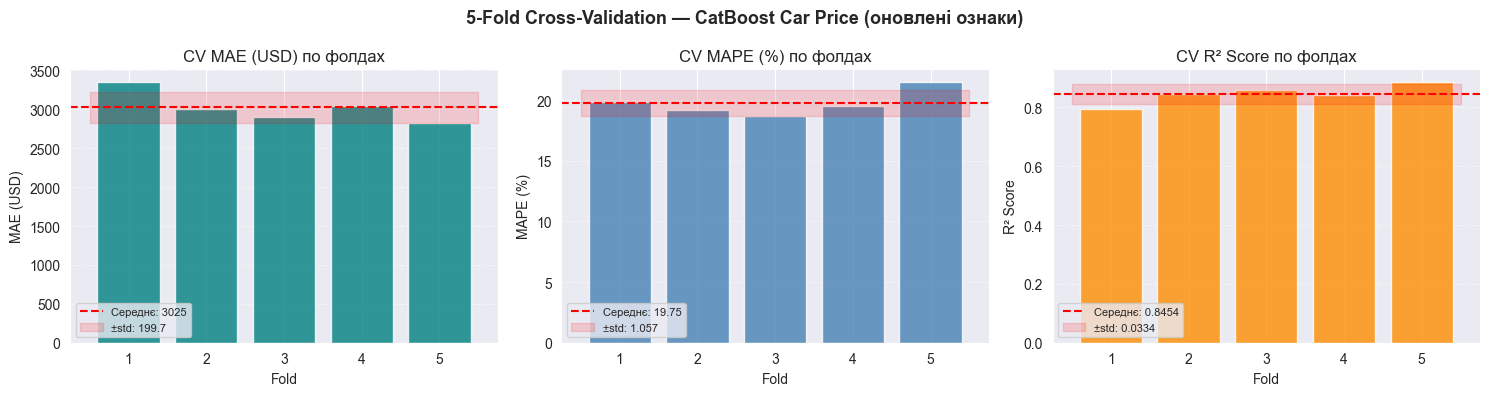

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    ('MAE',  'MAE (USD)',      'teal'),
    ('MAPE', 'MAPE (%)',       'steelblue'),
    ('R2',   'R² Score',       'darkorange'),
]

for ax, (col, label, color) in zip(axes, metrics):
    vals = cv_df[col]
    ax.bar(cv_df['fold'], vals, color=color, alpha=0.8, edgecolor='white')
    ax.axhline(vals.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Середнє: {vals.mean():.4g}')
    ax.fill_between(
        [0.5, N_FOLDS + 0.5],
        vals.mean() - vals.std(),
        vals.mean() + vals.std(),
        alpha=0.15, color='red', label=f'±std: {vals.std():.4g}'
    )
    ax.set_xlabel('Fold')
    ax.set_ylabel(label)
    ax.set_title(f'CV {label} по фолдах')
    ax.set_xticks(cv_df['fold'])
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle(f'{N_FOLDS}-Fold Cross-Validation — CatBoost Car Price (оновлені ознаки)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
mark_counts  = X_train_full['Mark'].value_counts()
model_counts = X_train_full['Model'].value_counts()

valid_marks  = mark_counts[mark_counts  >= MIN_COUNT].index
valid_models = model_counts[model_counts >= MIN_COUNT].index

for col, valid in [('Mark', valid_marks), ('Model', valid_models)]:
    X_train_full[col] = np.where(X_train_full[col].isin(valid), X_train_full[col], 'Other')
    X_test[col]       = np.where(X_test[col].isin(valid),       X_test[col],       'Other')

print(f"Унікальних марок  (>= {MIN_COUNT}): {len(valid_marks)}")
print(f"Унікальних моделей(>= {MIN_COUNT}): {len(valid_models)}")

Унікальних марок  (>= 10): 55
Унікальних моделей(>= 10): 303


In [17]:
Q1 = np.percentile(y_train_full, 25)
Q3 = np.percentile(y_train_full, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

train_mask   = (y_train_full >= lower_bound) & (y_train_full <= upper_bound)
X_train_full = X_train_full[train_mask].copy()
y_train_full = y_train_full[train_mask].copy()

print(f"Після видалення викидів: {len(X_train_full)} записів")
print(f"Межі IQR (USD): [{np.expm1(lower_bound):.0f}, {np.expm1(upper_bound):.0f}]")

Після видалення викидів: 15367 записів
Межі IQR (USD): [1135, 119052]


In [18]:
best_iters_mean = int(cv_df['best_iter'].mean())
print(f"Навчаємо фінальну модель на {len(X_train_full)} прикладах, iterations={best_iters_mean}...")

final_params = {**CATBOOST_PARAMS, 'iterations': best_iters_mean, 'early_stopping_rounds': None, 'verbose': 300}
model = CatBoostRegressor(**final_params)
model.fit(X_train_full, y_train_full, cat_features=cat_features)
print("Фінальну модель навчено!")

Навчаємо фінальну модель на 15367 прикладах, iterations=2689...
0:	learn: 0.6558995	total: 7.38ms	remaining: 19.8s
300:	learn: 0.1899831	total: 1.63s	remaining: 12.9s
600:	learn: 0.1690853	total: 3.16s	remaining: 11s
900:	learn: 0.1563153	total: 4.76s	remaining: 9.45s
1200:	learn: 0.1465989	total: 6.53s	remaining: 8.09s
1500:	learn: 0.1388646	total: 8.03s	remaining: 6.36s
1800:	learn: 0.1324633	total: 9.57s	remaining: 4.72s
2100:	learn: 0.1267663	total: 11.2s	remaining: 3.12s
2400:	learn: 0.1218058	total: 12.7s	remaining: 1.52s
2688:	learn: 0.1175046	total: 14.4s	remaining: 0us
Фінальну модель навчено!


## Оцінка якості моделі

In [19]:
y_pred_log   = model.predict(X_test)
y_pred       = np.expm1(y_pred_log)
y_test_real  = np.expm1(y_test)

mae  = mean_absolute_error(y_test_real, y_pred)
mape = mean_absolute_percentage_error(y_test_real, y_pred) * 100
r2   = r2_score(y_test_real, y_pred)

print(f"\n{'═'*45}")
print(f"  HOLD-OUT TEST RESULTS")
print(f"{'─'*45}")
print(f"  MAE   (середня похибка):  {mae:,.2f} USD")
print(f"  MAPE  (відносна похибка): {mape:.2f}%")
print(f"  R²    (детермінація):     {r2:.4f}")
print(f"  Median AE:                {np.median(np.abs(y_test_real.values - y_pred)):,.2f} USD")
print(f"{'═'*45}")
print(f"\nПорівняння CV vs Hold-out:")
print(f"  CV MAE = {cv_df['MAE'].mean():,.0f} USD  |  Test MAE = {mae:,.0f} USD  →  {'✓ консистентно' if abs(mae - cv_df['MAE'].mean()) / cv_df['MAE'].mean() < 0.1 else '⚠ розходження > 10%'}")


═════════════════════════════════════════════
  HOLD-OUT TEST RESULTS
─────────────────────────────────────────────
  MAE   (середня похибка):  2,884.37 USD
  MAPE  (відносна похибка): 19.34%
  R²    (детермінація):     0.8682
  Median AE:                1,251.79 USD
═════════════════════════════════════════════

Порівняння CV vs Hold-out:
  CV MAE = 3,025 USD  |  Test MAE = 2,884 USD  →  ✓ консистентно


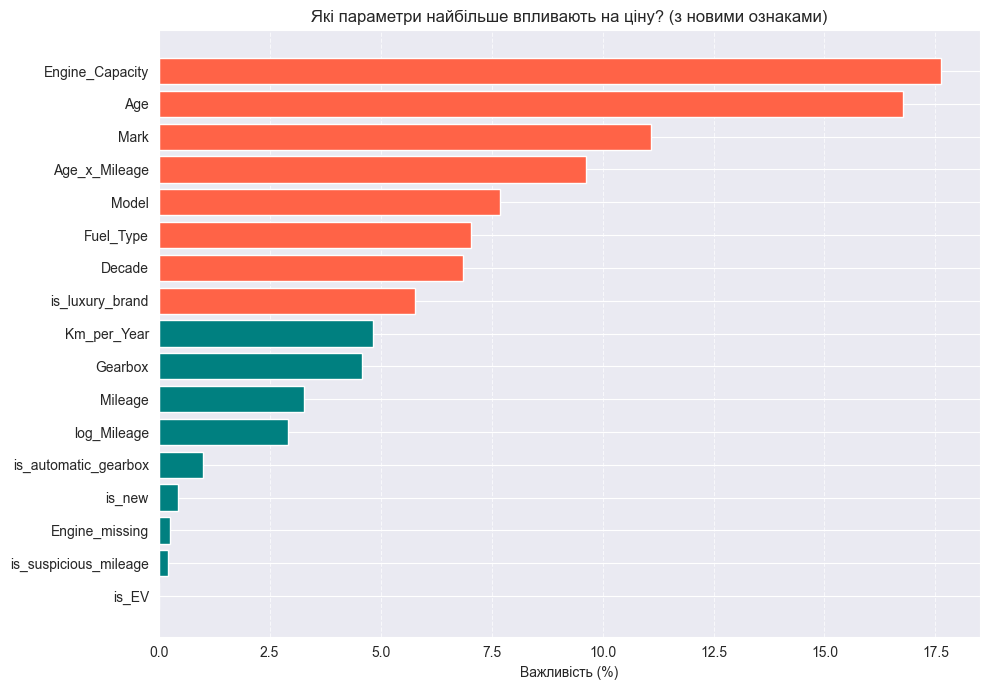

In [20]:
importance = model.get_feature_importance()
feat_imp = pd.Series(importance, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['tomato' if v > feat_imp.median() else 'teal' for v in feat_imp.values]
plt.barh(feat_imp.index, feat_imp.values, color=colors)
plt.xlabel('Важливість (%)')
plt.title('Які параметри найбільше впливають на ціну? (з новими ознаками)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

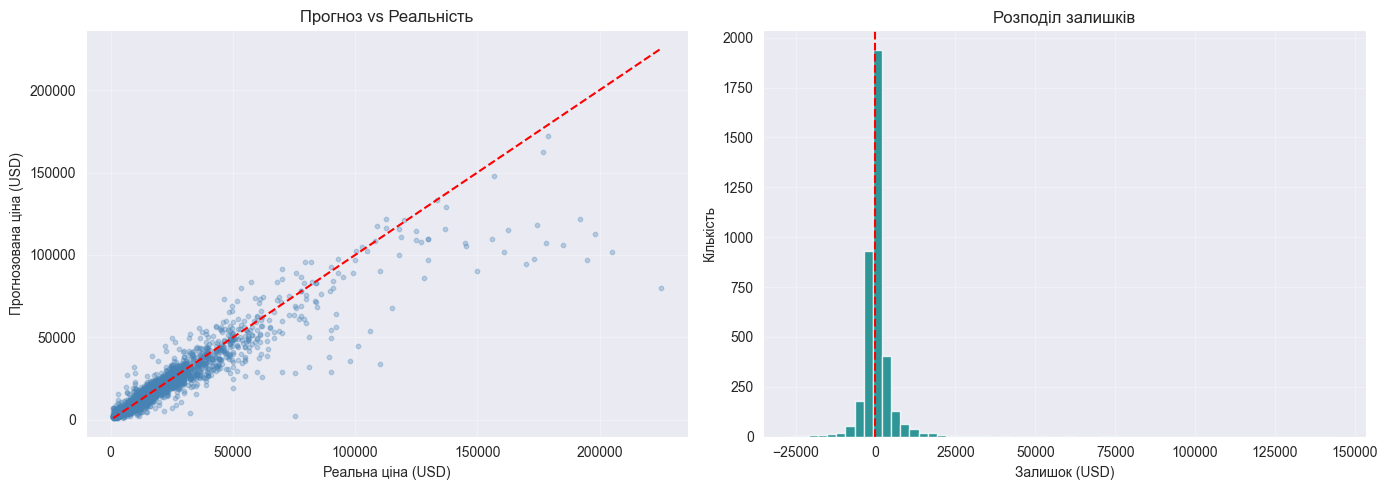

In [21]:
residuals = y_test_real.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_real, y_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    'r--', linewidth=1.5
)
axes[0].set_xlabel('Реальна ціна (USD)')
axes[0].set_ylabel('Прогнозована ціна (USD)')
axes[0].set_title('Прогноз vs Реальність')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=60, color='teal', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Залишок (USD)')
axes[1].set_ylabel('Кількість')
axes[1].set_title('Розподіл залишків')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Збереження артефактів

Окрім моделі зберігаємо `valid_categories.pkl` — довідники марок/моделей/КПП/палива/об'єму двигуна,
якими користується Streamlit-форма (`app.py`) для динамічних випадаючих списків. Раніше цей файл
очікувався бекендом, але жоден ноутбук його не генерував.

In [22]:
import os

MODEL_DIR  = "../src/backend/models"
MODEL_PATH = os.path.join(MODEL_DIR, "catboost_car_price_model.cbm")

os.makedirs(MODEL_DIR, exist_ok=True)
model.save_model(MODEL_PATH)
print(f"Модель збережено у {MODEL_PATH}")

Модель збережено у ../src/backend/models\catboost_car_price_model.cbm


In [23]:
# valid_categories.pkl — довідники для UI (побудовані з очищеного df, без витоку test-даних:
# це лише перелік допустимих значень для форми, а не навчальні дані моделі)
valid_marks_list = sorted(df['Mark'].unique().tolist())

mark_model_mapping = (
    df.groupby('Mark')['Model']
    .apply(lambda s: sorted(s.dropna().unique().tolist()))
    .to_dict()
)

def _nested_map(value_col):
    out = {}
    for mark, g in df.groupby('Mark'):
        out[mark] = {}
        for model_name, g2 in g.groupby('Model'):
            out[mark][model_name] = sorted(g2[value_col].dropna().unique().tolist())
    return out

engine_mapping  = _nested_map('Engine_Capacity')
fuel_mapping    = _nested_map('Fuel_Type')
gearbox_mapping = _nested_map('Gearbox')

valid_categories = {
    'valid_marks': valid_marks_list,
    'mark_model_mapping': mark_model_mapping,
    'engine_mapping': engine_mapping,
    'fuel_mapping': fuel_mapping,
    'gearbox_mapping': gearbox_mapping,
}

CATEGORIES_PATH = os.path.join(MODEL_DIR, "valid_categories.pkl")
joblib.dump(valid_categories, CATEGORIES_PATH)
print(f"Категорії збережено у {CATEGORIES_PATH}")
print(f"Марок: {len(valid_marks_list)}")

Категорії збережено у ../src/backend/models\valid_categories.pkl
Марок: 130
